# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 05: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_05_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993. https://doi.org/10.24432/C5859H.</font>

O dataset pertence ao domínio automotivo e seu objetivo é usar dos dados para fazer regressão, buscando prever o consumo de galões de gasolina por milhas. O dataset possui informações categóricas e numéricas.

## <font color='green'>Preparação</font>

In [ ]:
!pip install pandas scikit-learn ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Importar o dataset Auto MPG (ID 9)
auto_mpg = fetch_ucirepo(id=9)

# Extrair as variáveis independentes (X) e a variável alvo (y)
X = auto_mpg.data.features
y = auto_mpg.data.targets

df = pd.concat([X,y], axis=1)

# Ver as primeiras linhas
display(df.head())

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [ ]:
df_sem_na = df.dropna()
print(f"Quantidade de amostras removidas {len(df) - len(df_sem_na)}")

Quantidade de amostras removidas 6


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

Text(0.5, 0, 'Valor de Y')

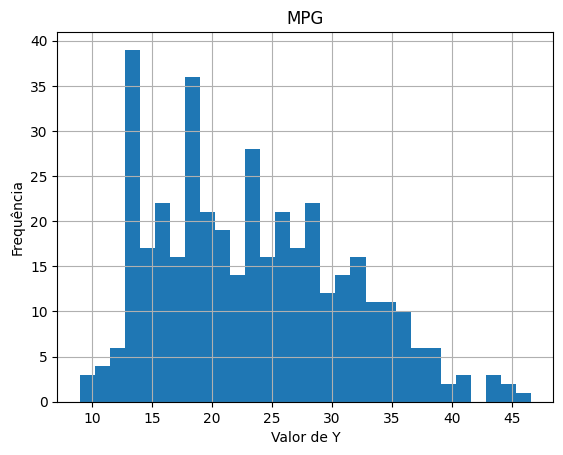

In [ ]:
import matplotlib.pyplot as plt

plt.hist(y['mpg'], bins=30)
plt.grid()
plt.title("MPG")
plt.ylabel("Frequência")
plt.xlabel("Valor de Y")

### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

A distribuição do histograma nos diz que a maior parte do consumo por galão está entre 10 e 36, tendo alguns picos em certos valores desse intervalo.

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

Text(0.5, 0, 'Peso do Veículo')

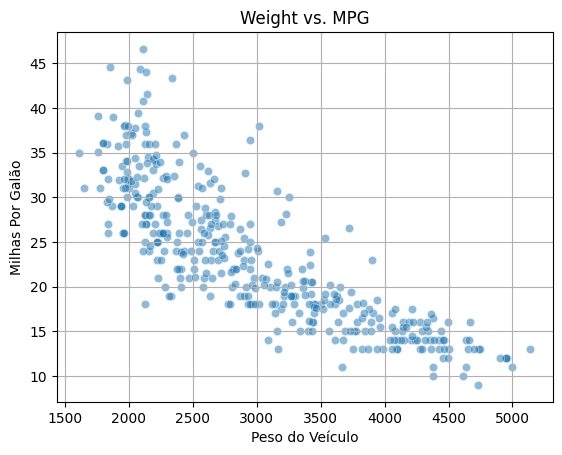

In [ ]:
plt.scatter(df_sem_na['weight'], df_sem_na['mpg'], alpha=0.5, edgecolors='white', linewidths=0.5)
plt.grid()
plt.title("Weight vs. MPG")
plt.ylabel("Milhas Por Galão")
plt.xlabel("Peso do Veículo")

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

Ela apresenta um comportamento não linear, pois podemos identificar uma exponencial de potencia negativa na relação entre ambos. A relação linear não capturaria o padrão do decrescimento negativo exponencial apresentado e se elevassemos o grau, a relação perderia o sentido em que carros mais pesados consumem mais em relação a carros mais leves.

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

In [ ]:
from sklearn.model_selection import KFold, train_test_split


X_train_full, X_test, y_train_full, y_test = train_test_split(df_sem_na['weight'], df_sem_na['mpg'], test_size=0.2, random_state=42)

Text(0.5, 0, 'Peso do Veículo')

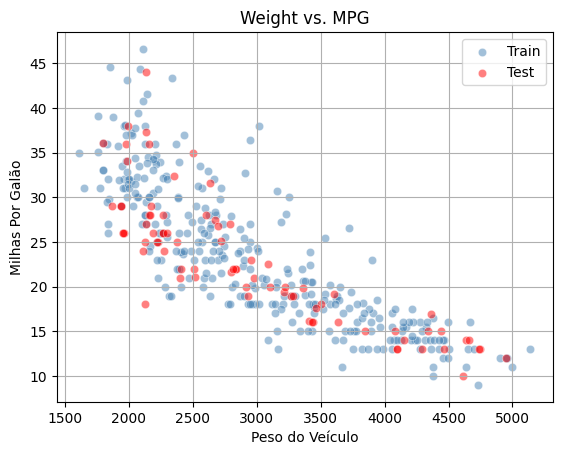

In [ ]:
plt.scatter(X_train_full, y_train_full, color="steelblue", alpha=0.5, edgecolors='white', linewidths=0.5, label="Train")
plt.scatter(X_test, y_test, color="red", alpha=0.5, edgecolors='white', linewidths=0.5, label="Test")
plt.legend()
plt.grid()
plt.title("Weight vs. MPG")
plt.ylabel("Milhas Por Galão")
plt.xlabel("Peso do Veículo")


### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

O conjunto de treinamento e de teste parecem ser bem representativos em relação ao conjunto original, além disso, ambos parecem bem divididos e parecem capturar bem o comportamento da dispersão.

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

modelo_linear = LinearRegression()

modelo_linear.fit(X = X_train_full.values.reshape(-1,1), y = y_train_full)

y_pred_train = modelo_linear.predict(X_train_full.values.reshape(-1,1))
y_pred_test = modelo_linear.predict(X_test.values.reshape(-1,1))

print("Para o teste:")
print(f"Valor do MSE: {mean_squared_error(y_test, y_pred_test)}")
print(f"Valor do MAE: {mean_absolute_error(y_test, y_pred_test)}")
print(f"Valor do R2: {r2_score(y_test, y_pred_test)}\n")
print("Para o treino:")
print(f"Valor do MSE: {mean_squared_error(y_train_full, y_pred_train)}")
print(f"Valor do MAE: {mean_absolute_error(y_train_full, y_pred_train)}")
print(f"Valor do R2: {r2_score(y_train_full, y_pred_train)}\n")

Para o teste:
Valor do MSE: 17.693388269545686
Valor do MAE: 3.4641211922147592
Valor do R2: 0.6533466675646016

Para o treino:
Valor do MSE: 19.04510619658238
Valor do MAE: 3.2855106233763385
Valor do R2: 0.6981745885310532



### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

O modelo não sofre de overfitting, visto que é possível ver que ele não decorou o modelo de treino, mas ele sofre de underfitting, visto pelo MAE que é alto, 3.4 em um gráfico que vai de 10 a 46, muito provavelmente devido a falta de informação de outras características que influenciam no consumo.

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

# Treinar esse melhor modelo com todo o conjunto de treinamento
modelo_poly = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LinearRegression()
)
modelo_poly.fit(X_train_full.values.reshape(-1,1), y_train_full)

# Avaliar no conjunto de treinamento
y_train_pred = modelo_poly.predict(X_train_full.values.reshape(-1,1))
train_error_mse = mean_squared_error(y_train_full, y_train_pred)
train_error_mae = mean_absolute_error(y_train_full, y_train_pred)
train_error_r2 = r2_score(y_train_full, y_train_pred)
print(f"Erro no conjunto de treinamento (MSE) com grau 2: {train_error_mse:.4f}")
print(f"Erro no conjunto de treinamento (MAE) com grau 2: {train_error_mae:.4f}")
print(f"Erro no conjunto de treinamento (R2) com grau 2: {train_error_r2:.4f}\n")

# Avaliar no conjunto de teste
y_test_pred = modelo_poly.predict(X_test.values.reshape(-1,1))
test_error_mse = mean_squared_error(y_test, y_test_pred)
test_error_mae = mean_absolute_error(y_test,y_test_pred)
test_error_r2 = r2_score(y_test,y_test_pred)
print(f"Erro no conjunto de teste (MSE) com grau 2: {test_error_mse:.4f}")
print(f"Erro no conjunto de teste (MAE) com grau 2: {test_error_mae:.4f}")
print(f"Erro no conjunto de teste (R2) com grau 2: {test_error_r2:.4f}")


Erro no conjunto de treinamento (MSE) com grau 2: 17.5830
Erro no conjunto de treinamento (MAE) com grau 2: 3.0798
Erro no conjunto de treinamento (R2) com grau 2: 0.7213

Erro no conjunto de teste (MSE) com grau 2: 16.6891
Erro no conjunto de teste (MAE) com grau 2: 3.1383
Erro no conjunto de teste (R2) com grau 2: 0.6730


### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

O modelo deu uma melhorada no geral e ganhou mais flexividade com o aumento do grau, mas a limitação da falta de informações para o modelo, no quesito de ter apenas a informação do peso, gera underfitting.

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

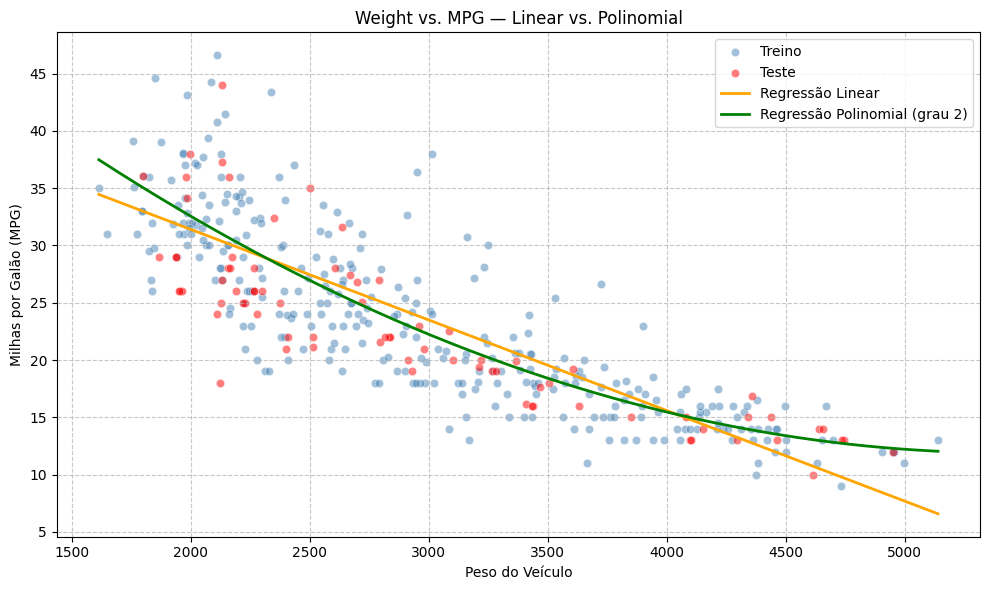

In [ ]:
import numpy as np

# Criar intervalo contínuo de valores de X para as curvas
X_range = np.linspace(X_train_full.min(), X_train_full.max(), 300).reshape(-1, 1)

# Previsões dos dois modelos para esse intervalo
y_linear = modelo_linear.predict(X_range)
y_poly = modelo_poly.predict(X_range)

# Gráfico
plt.figure(figsize=(10, 6))

# Scatter treino e teste
plt.scatter(X_train_full, y_train_full, color='steelblue', alpha=0.5, edgecolors='white', linewidths=0.5, label='Treino')
plt.scatter(X_test, y_test, color='red', alpha=0.5, edgecolors='white', linewidths=0.5, label='Teste')

# Curvas de regressão
plt.plot(X_range, y_linear, color='orange', linewidth=2, label='Regressão Linear')
plt.plot(X_range, y_poly, color='green', linewidth=2, label='Regressão Polinomial (grau 2)')

plt.grid(linestyle='--', alpha=0.7)
plt.title('Weight vs. MPG — Linear vs. Polinomial')
plt.xlabel('Peso do Veículo')
plt.ylabel('Milhas por Galão (MPG)')
plt.legend()
plt.tight_layout()
plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

Com base no gráfico que foi gerado, a regressão polinomial consegue se ajustar melhor aos dados do que o ajuste linear. Dito isso, a relação entre weight e mpg ainda parece ser não linear, se assemelhando mais a uma exponencial negativa que a um polinômio do segundo grau.

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

Os resultados observados parecem consistentes com as análises métricas no sentido de que a regressão polinomial se ajusta melhor que o ajuste linear. Dito isso, ambos os ajustes ainda não conseguem capturar bem o comportamento dos veículos mais leves, tendo um alto viés na região esquerda, além disso, ambos os ajustes capturam de forma geral o comportamento, mas generalizaram tanto que ambos acabaram em underfitting, sendo apenas que o polinomial está um pouco menos que o linear.

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

# Treinar esse melhor modelo com todo o conjunto de treinamento
modelo_poly = make_pipeline(
    PolynomialFeatures(degree=20, include_bias=False),
    StandardScaler(),
    LinearRegression()
)
modelo_poly.fit(X_train_full.values.reshape(-1,1), y_train_full)

# Avaliar no conjunto de treinamento
y_train_pred = modelo_poly.predict(X_train_full.values.reshape(-1,1))
train_error_mse = mean_squared_error(y_train_full, y_train_pred)
train_error_mae = mean_absolute_error(y_train_full, y_train_pred)
train_error_r2 = r2_score(y_train_full, y_train_pred)
print(f"Erro no conjunto de treinamento (MSE) com grau 20: {train_error_mse:.4f}")
print(f"Erro no conjunto de treinamento (MAE) com grau 20: {train_error_mae:.4f}")
print(f"Erro no conjunto de treinamento (R2) com grau 20: {train_error_r2:.4f}\n")

# Avaliar no conjunto de teste
y_test_pred = modelo_poly.predict(X_test.values.reshape(-1,1))
test_error_mse = mean_squared_error(y_test, y_test_pred)
test_error_mae = mean_absolute_error(y_test,y_test_pred)
test_error_r2 = r2_score(y_test,y_test_pred)
print(f"Erro no conjunto de teste (MSE) com grau 20: {test_error_mse:.4f}")
print(f"Erro no conjunto de teste (MAE) com grau 20: {test_error_mae:.4f}")
print(f"Erro no conjunto de teste (R2) com grau 20: {test_error_r2:.4f}")


Erro no conjunto de treinamento (MSE) com grau 20: 16.8469
Erro no conjunto de treinamento (MAE) com grau 20: 3.0324
Erro no conjunto de treinamento (R2) com grau 20: 0.7330

Erro no conjunto de teste (MSE) com grau 20: 17.2814
Erro no conjunto de teste (MAE) com grau 20: 3.1653
Erro no conjunto de teste (R2) com grau 20: 0.6614


De forma mais suave do que o esperado, o desempenho do treino aumentou e do teste diminui, o que é sinal de início de overfitting. O overfitting não está tão escancarado quanto o esperado devido ao StandardScaler que contém o overfitting e por usarmos apenas uma feature, mas ainda assim é aparente.

## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [ ]:
X_full = df_sem_na.drop(columns='mpg')
y_full = df_sem_na['mpg']

In [ ]:
X_full.isnull().sum()

,0
displacement,0
cylinders,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0


In [ ]:
from sklearn.linear_model import SGDRegressor

modelo_sgd = SGDRegressor()
modelo_sgd.fit(X_full, y_full)

y_pred = modelo_sgd.predict(X_full)
print(f"R²: {r2_score(y_full, y_pred):.4f}\n")
print("Coeficientes:")
coeficientes = modelo_sgd.coef_
for feature, coef in zip(X_full.columns, coeficientes):
    print(f"{feature}: {coef:.4f}")

R²: -15313723822248592111535390720.0000

Coeficientes:
displacement: -491003510347.4304
cylinders: 43082876343.8759
horsepower: -2672999787604.6875
weight: -199585951944.0663
acceleration: 260172827604.1176
model_year: 689638201648.9095
origin: 71897062293.2992


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [ ]:
# Treinar esse melhor modelo com todo o conjunto de treinamento
modelo_poly = make_pipeline(
    StandardScaler(),
    SGDRegressor()
)
modelo_poly.fit(X_full, y_full)

# Avaliar no conjunto de treinamento
y_train_pred = modelo_poly.predict(X_full)
train_error_mse = mean_squared_error(y_full, y_train_pred)
train_error_mae = mean_absolute_error(y_full, y_train_pred)
train_error_r2 = r2_score(y_full, y_train_pred)
print(f"Erro no conjunto(MSE) com grau 2: {train_error_mse:.4f}")
print(f"Erro no conjunto(MAE) com grau 2: {train_error_mae:.4f}")
print(f"Erro no conjunto(R2) com grau 2: {train_error_r2:.4f}")

Erro no conjunto(MSE) com grau 2: 10.9311
Erro no conjunto(MAE) com grau 2: 2.5073
Erro no conjunto(R2) com grau 2: 0.8201


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

A normalização é importante pois o SGDRegressor tenta usar valores na casa de 2000-5000 diretamente para atualizar seus pesos a cada iteração. Dessa forma, seus passos ficam descontrolados e os coeficientes não conseguem convergir para a solução. Nesse sentido, quando usamos o StandardScaler, o SGDRegressor não sofre tanta instabilidade, pois  todos os valores são colocados em uma escala padronizada com média 0 e desvio padrão 1, o que torna os passos do seu gradiente mais estáveis e previsíveis.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [ ]:
from sklearn.linear_model import Lasso

# Treinar esse melhor modelo com todo o conjunto de treinamento
modelo_lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=1.0)
)
modelo_lasso.fit(X_full, y_full)
coeficientes = modelo_lasso.named_steps['lasso'].coef_
for feature, coef in zip(X_full.columns, coeficientes):
    print(f"{feature}: {coef:.4f}")

displacement: -0.0000
cylinders: -0.0000
horsepower: -0.1677
weight: -4.5455
acceleration: 0.0000
model_year: 1.9944
origin: 0.3083


Em comparação com o SGDRegressor, o LASSO possui coeficientes com magnitudes muito menores, sendo o primeiro na casa de bilhões e o segundo tendo uma magnitude máxima de quase 5, possuindo até mesmo coeficientes com valores nulos. Essa mudança drástica se deve tanto a normalização dos valores, quanto a própria natureza do LASSO de penalizar coeficientes pequenos até zera-los. Dito isso, a normalização permite que o modelo possa comparar as features de uma forma justa, com todos na mesma escala, sendo de extrema importância para modelos que se baseiam em gradiente descendente e regularização.

### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

Para alpha = 0.1:

In [ ]:
from sklearn.linear_model import Lasso

# Treinar esse melhor modelo com todo o conjunto de treinamento
modelo_lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)
modelo_lasso.fit(X_full, y_full)
coeficientes = modelo_lasso.named_steps['lasso'].coef_
for feature, coef in zip(X_full.columns, coeficientes):
  if coef != 0:
    print(f"{feature}: {coef:.4f}")

horsepower: -0.3417
weight: -4.7402
acceleration: 0.0305
model_year: 2.6473
origin: 0.8902


Para alpha = 1.0:

In [ ]:
from sklearn.linear_model import Lasso

# Treinar esse melhor modelo com todo o conjunto de treinamento
modelo_lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=1.0)
)
modelo_lasso.fit(X_full, y_full)
coeficientes = modelo_lasso.named_steps['lasso'].coef_
for feature, coef in zip(X_full.columns, coeficientes):
  if coef != 0:
    print(f"{feature}: {coef:.4f}")

horsepower: -0.1677
weight: -4.5455
model_year: 1.9944
origin: 0.3083


Para alpha = 5.0:

In [ ]:
from sklearn.linear_model import Lasso

# Treinar esse melhor modelo com todo o conjunto de treinamento
modelo_lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=5.0)
)
modelo_lasso.fit(X_full, y_full)
coeficientes = modelo_lasso.named_steps['lasso'].coef_
for feature, coef in zip(X_full.columns, coeficientes):
  if coef != 0:
    print(f"{feature}: {coef:.4f}")

weight: -1.4874


A medida que a penalidade do LASSO aumenta, a complexidade do modelo tende a diminuir. Isso se deve a própria natureza do LASSO, pois quando aumentamos a penalidade, as features tendem a ter coeficientes muito baixos ou até mesmo zerados, diminuindo, assim, a complexidade do modelo.
